In [3]:
from dotenv import load_dotenv
import os
import numpy as np
import torch
from sklearn.model_selection import train_test_split
load_dotenv('.env')
mnist_train_fp = os.getenv('MNIST_TRAIN_FILEPATH')
mnist_test_fp = os.getenv('MNIST_TEST_FILEPATH')
mnist_train = np.load(mnist_train_fp)
mnist_test = np.load(mnist_test_fp)
print(f"Train dataset file path: {mnist_train_fp}")
print(f"Test dataset file path: {mnist_test_fp}")

Train dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\mnist_dataset\mnist_train.npz
Test dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\mnist_dataset\mnist_test.npz


In [4]:
SEED = 42
torch.manual_seed(SEED)

X = mnist_train['images']
Y = mnist_train['labels']
X_test = mnist_test['images']
Y_test = mnist_test['labels']


#Aplanar la imagen
X = X.reshape(X.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

#escalar a [0,1]
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=Y)

In [5]:
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).long()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).long()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).long()

In [6]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class DenseNet(nn.Module):
    def __init__ (self):
        super(DenseNet, self).__init__()
        self.layer1 = nn.Linear(784, 128)
        self.layer2 = nn.Linear(128, 10)
    def forward(self, x):
        output = F.relu(self.layer1(x))
        output = self.layer2(output)
        return output


In [8]:
import torch.optim as optim

model = DenseNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
import time

epoch_count = 10

train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.8f} seconds")

Epoch: 1. Train Loss: 0.3700, Eval Loss: 0.2157
Epoch: 2. Train Loss: 0.1736, Eval Loss: 0.1512
Epoch: 3. Train Loss: 0.1242, Eval Loss: 0.1321
Epoch: 4. Train Loss: 0.0946, Eval Loss: 0.1153
Epoch: 5. Train Loss: 0.0749, Eval Loss: 0.0971
Epoch: 6. Train Loss: 0.0603, Eval Loss: 0.0955
Epoch: 7. Train Loss: 0.0492, Eval Loss: 0.0940
Epoch: 8. Train Loss: 0.0405, Eval Loss: 0.0921
Epoch: 9. Train Loss: 0.0324, Eval Loss: 0.0860
Epoch: 10. Train Loss: 0.0276, Eval Loss: 0.0866
Execution time: 36.49850610 seconds


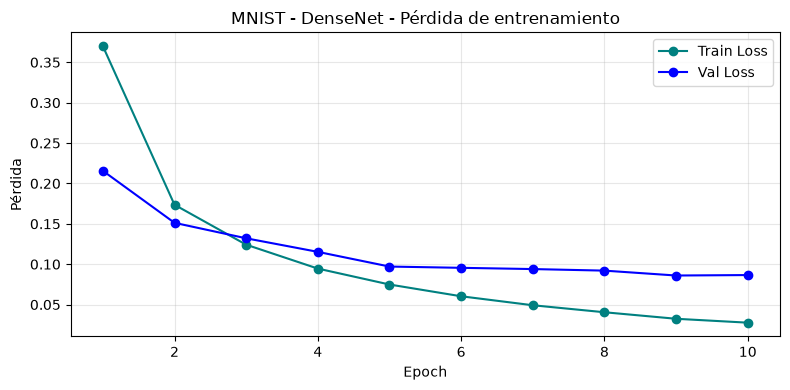

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_history, marker="o", color="teal", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="blue", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Pérdida")
plt.title("MNIST - DenseNet - Pérdida de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    loss = loss_function(preds, Y_test_tensor).item()
    predicted_classes = torch.argmax(preds, dim=1)
    accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")

Loss of the model: 0.0763
Accuracy of the model: 0.9780


In [12]:
mnist_accuracy = accuracy
mnist_test_loss = loss
print(f"Referencia guardada - MNIST Dense Accuracy: {mnist_accuracy:.4f}")


Referencia guardada - MNIST Dense Accuracy: 0.9780


In [13]:
#PARTE 2
fmnist_train_fp = os.getenv('FMNIST_TRAIN_FILEPATH')
fmnist_test_fp = os.getenv('FMNIST_TEST_FILEPATH')
fmnist_train = np.load(fmnist_train_fp)
fmnist_test = np.load(fmnist_test_fp)
print(f"Train dataset file path: {fmnist_train_fp}")
print(f"Test dataset file path: {fmnist_test_fp}")


Train dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\fmnist_dataset\fmnist_train.npz
Test dataset file path: C:\Users\NICKY\Documents\Universidad\Q3 2026\Redes neuronales\Lab2\fmnist_dataset\fmnist_test.npz


In [14]:
X = fmnist_train["images"]
Y = fmnist_train["labels"]
X_test = fmnist_test["images"]
Y_test = fmnist_test["labels"]

X = X.reshape(X.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=SEED, stratify=Y
)


In [15]:
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).long()
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).long()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).long()


In [16]:
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
model = DenseNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.8f} seconds")


Epoch: 1. Train Loss: 0.5739, Eval Loss: 0.4270
Epoch: 2. Train Loss: 0.4118, Eval Loss: 0.3783
Epoch: 3. Train Loss: 0.3693, Eval Loss: 0.3752
Epoch: 4. Train Loss: 0.3447, Eval Loss: 0.3450
Epoch: 5. Train Loss: 0.3218, Eval Loss: 0.3388
Epoch: 6. Train Loss: 0.3101, Eval Loss: 0.3270
Epoch: 7. Train Loss: 0.2974, Eval Loss: 0.3317
Epoch: 8. Train Loss: 0.2846, Eval Loss: 0.3230
Epoch: 9. Train Loss: 0.2736, Eval Loss: 0.3721
Epoch: 10. Train Loss: 0.2642, Eval Loss: 0.3131
Execution time: 34.01618090 seconds


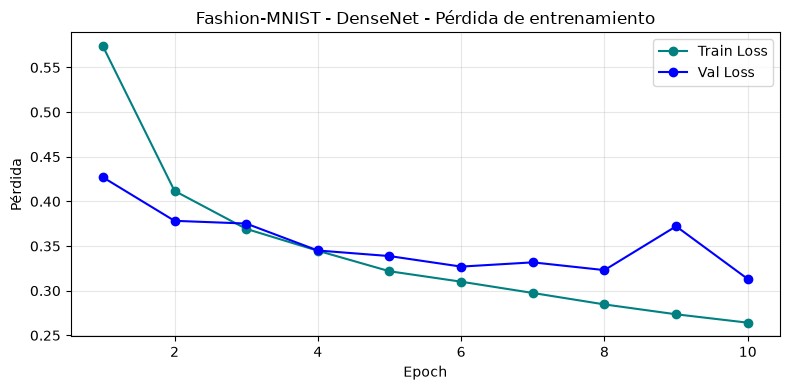

In [19]:
epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_history, marker="o", color="teal", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="blue", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Pérdida")
plt.title("Fashion-MNIST - DenseNet - Pérdida de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
model.eval()
with torch.no_grad():
    preds = model(X_test_tensor)
    loss = loss_function(preds, Y_test_tensor).item()
    predicted_classes = torch.argmax(preds, dim=1)
    accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

fmnist_accuracy = accuracy
fmnist_test_loss = loss

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")


Loss of the model: 0.3417
Accuracy of the model: 0.8800


In [21]:
print(f"{'Dataset':<25}{'Precisión de Prueba':>22}")
print(f"{'MNIST (Parte 1)':<25}{mnist_accuracy:>22.4f}")
print(f"{'Fashion-MNIST (Parte 2)':<25}{fmnist_accuracy:>22.4f}")


Dataset                     Precisión de Prueba
MNIST (Parte 1)                          0.9780
Fashion-MNIST (Parte 2)                  0.8800


In [22]:
#Parte 3
X_train_img_tensor = X_train_tensor.view(-1, 1, 28, 28)
X_val_img_tensor = X_val_tensor.view(-1, 1, 28, 28)
X_test_img_tensor = X_test_tensor.view(-1, 1, 28, 28)

In [23]:
train_dataset = TensorDataset(X_train_img_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_img_tensor, Y_val_tensor)
test_dataset = TensorDataset(X_test_img_tensor, Y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [24]:
class ConvNet(nn.Module):
    def __init__ (self):
        super (ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)

        self.fc_out = nn.Linear(32*7*7, 10)

    def forward(self, x):
        output = self.pool(F.relu(self.conv1(x)))
        output = self.pool(F.relu(self.conv2(output)))
        output = output.view(output.size(0), -1)
        output = self.fc_out(output)
        return output


In [25]:
model = ConvNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
train_loss_history: list[float] = []
val_loss_history: list[float] = []

start_time = time.perf_counter()
for epoch in range(epoch_count):
    model.train()

    train_running_loss = 0.0
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = loss_function(preds, y_batch)

        loss.backward()
        optimizer.step()
        train_running_loss += loss.item()

    val_running_loss = 0.0
    model.eval()
    for x_batch, y_batch in val_loader:
        with torch.no_grad():
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            val_running_loss += loss.item()

    train_epoch_loss = train_running_loss / len(train_loader)
    val_epoch_loss = val_running_loss / len(val_loader)
    train_loss_history.append(train_epoch_loss)
    val_loss_history.append(val_epoch_loss)
    print(f"Epoch: {epoch+1}. Train Loss: {train_epoch_loss:.4f}, Eval Loss: {val_epoch_loss:.4f}")

end_time = time.perf_counter()
print(f"Training time: {end_time - start_time:.2f} seconds")

Epoch: 1. Train Loss: 0.5718, Eval Loss: 0.3901
Epoch: 2. Train Loss: 0.3656, Eval Loss: 0.3350
Epoch: 3. Train Loss: 0.3258, Eval Loss: 0.3053
Epoch: 4. Train Loss: 0.2982, Eval Loss: 0.2923
Epoch: 5. Train Loss: 0.2769, Eval Loss: 0.2860
Epoch: 6. Train Loss: 0.2597, Eval Loss: 0.2674
Epoch: 7. Train Loss: 0.2507, Eval Loss: 0.2784
Epoch: 8. Train Loss: 0.2376, Eval Loss: 0.2684
Epoch: 9. Train Loss: 0.2277, Eval Loss: 0.2816
Epoch: 10. Train Loss: 0.2210, Eval Loss: 0.2585
Training time: 205.52 seconds


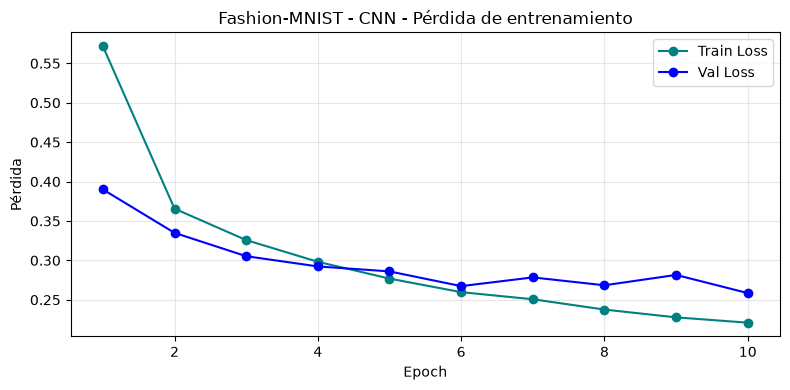

In [27]:
epochs = range(1, epoch_count + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_history, marker="o", color="teal", label="Train Loss")
plt.plot(epochs, val_loss_history, marker="o", color="blue", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Pérdida")
plt.title("Fashion-MNIST - CNN - Pérdida de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [28]:
model.eval()
with torch.no_grad():
    preds = model(X_test_img_tensor)
    loss = loss_function(preds, Y_test_tensor).item()
    predicted_classes = torch.argmax(preds, dim=1)
    accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

cnn_accuracy = accuracy
cnn_test_loss = loss

print(f"Loss of the model: {loss:.4f}")
print(f"Accuracy of the model: {accuracy:.4f}")


Loss of the model: 0.2726
Accuracy of the model: 0.9010


In [29]:
dense_param_count = sum(p.numel() for p in DenseNet().parameters())
cnn_param_count = sum(p.numel() for p in model.parameters())

print(f"DenseNet parameter count: {dense_param_count}")
print(f"ConvNet parameter count: {cnn_param_count}")


DenseNet parameter count: 101770
ConvNet parameter count: 20490


In [30]:
print(f"{'Modelo / Dataset':<32}{'Precisión de Prueba':>22}{'Parámetros':>15}")
print(f"{'Densa en MNIST (Parte 1)':<32}{mnist_accuracy:>22.4f}{dense_param_count:>15}")
print(f"{'Densa en Fashion-MNIST (Parte 2)':<32}{fmnist_accuracy:>22.4f}{dense_param_count:>15}")
print(f"{'CNN en Fashion-MNIST (Parte 3)':<32}{cnn_accuracy:>22.4f}{cnn_param_count:>15}")


Modelo / Dataset                   Precisión de Prueba     Parámetros
Densa en MNIST (Parte 1)                        0.9780         101770
Densa en Fashion-MNIST (Parte 2)                0.8800         101770
CNN en Fashion-MNIST (Parte 3)                  0.9010          20490


In [31]:
from sklearn.metrics import classification_report

y_true = Y_test_tensor.numpy()
y_pred = predicted_classes.numpy()

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1000
           1       0.98      0.98      0.98      1000
           2       0.87      0.81      0.84      1000
           3       0.90      0.91      0.91      1000
           4       0.83      0.85      0.84      1000
           5       0.97      0.98      0.98      1000
           6       0.69      0.76      0.72      1000
           7       0.96      0.96      0.96      1000
           8       0.99      0.96      0.98      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [32]:
class ConvNetDropout(nn.Module):
    def __init__(self, dropout_p):
        super(ConvNetDropout, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout(p=dropout_p)
        self.fc_out = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        output = self.pool(F.relu(self.conv1(x)))
        output = self.pool(F.relu(self.conv2(output)))
        output = output.view(output.size(0), -1)
        output = self.dropout(output)
        output = self.fc_out(output)
        return output


In [33]:
dropout_rates = [0.0, 0.2, 0.4, 0.6]
dropout_results = {}

for dropout_p in dropout_rates:
    torch.manual_seed(SEED) 
    model = ConvNetDropout(dropout_p)
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_loss_history: list[float] = []
    val_loss_history: list[float] = []

    for epoch in range(epoch_count):
        model.train()
        train_running_loss = 0.0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(x_batch)
            loss = loss_function(preds, y_batch)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()

        val_running_loss = 0.0
        model.eval()
        for x_batch, y_batch in val_loader:
            with torch.no_grad():
                preds = model(x_batch)
                loss = loss_function(preds, y_batch)
                val_running_loss += loss.item()

        train_loss_history.append(train_running_loss / len(train_loader))
        val_loss_history.append(val_running_loss / len(val_loader))

    model.eval()
    with torch.no_grad():
        preds = model(X_test_img_tensor)
        predicted_classes = torch.argmax(preds, dim=1)
        test_accuracy = (predicted_classes == Y_test_tensor).float().mean().item()

    dropout_results[dropout_p] = {
        "test_accuracy": test_accuracy,
        "final_train_loss": train_loss_history[-1],
        "final_val_loss": val_loss_history[-1],
    }
    print(f"dropout_p={dropout_p} - Test Acc: {test_accuracy:.4f} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")


dropout_p=0.0 - Test Acc: 0.8837 - Train Loss: 0.2246 - Val Loss: 0.2844
dropout_p=0.2 - Test Acc: 0.9028 - Train Loss: 0.2554 - Val Loss: 0.2454
dropout_p=0.4 - Test Acc: 0.8994 - Train Loss: 0.2828 - Val Loss: 0.2554
dropout_p=0.6 - Test Acc: 0.8948 - Train Loss: 0.3220 - Val Loss: 0.2669


In [34]:
print(f"{'dropout_p':<12}{'Precisión de Prueba':>22}{'Train Loss':>14}{'Val Loss':>14}")
for p, r in dropout_results.items():
    print(f"{p:<12}{r['test_accuracy']:>22.4f}{r['final_train_loss']:>14.4f}{r['final_val_loss']:>14.4f}")


dropout_p      Precisión de Prueba    Train Loss      Val Loss
0.0                         0.8837        0.2246        0.2844
0.2                         0.9028        0.2554        0.2454
0.4                         0.8994        0.2828        0.2554
0.6                         0.8948        0.3220        0.2669
